### Note: Markdown cells are written by GPT-5.2-Codex

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pytensor
import pytensor.tensor as pt

rng = np.random.default_rng(1234)

In [26]:
def sample_gaussian_mixture(n, mus, sigmas, weights, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    mus = np.asarray(mus, dtype=float)
    sigmas = np.asarray(sigmas, dtype=float)
    weights = np.asarray(weights, dtype=float)
    weights = weights / np.sum(weights)
    k = mus.shape[0]
    z = rng.choice(k, size=n, p=weights)
    mu = mus[z]
    if mu.ndim == 1:
        sigma = sigmas if sigmas.ndim == 0 else sigmas[z]
        return rng.normal(loc=mu, scale=sigma, size=mu.shape)
    sigma = sigmas if sigmas.ndim == 0 else sigmas[z]
    sigma = np.asarray(sigma, dtype=float)
    if sigma.ndim == 1:
        sigma = sigma[:, None]
    return rng.normal(loc=mu, scale=sigma, size=mu.shape)

n = 1500
d = 3
sigma = 1.0
mus = np.array([
    [-3.0, -1.0, 0.5],
    [-0.5, 1.5, 2.0],
    [2.5, -2.0, 1.0],
], dtype=float)
sigmas = np.array([0.6, 0.8, 1.0], dtype=float)
weights = [0.25, 0.35, 0.40]
y = sample_gaussian_mixture(n, mus=mus, sigmas=sigmas, weights=weights, rng=rng)

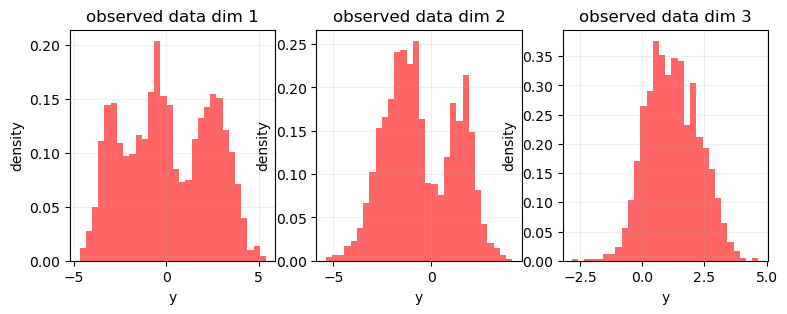

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for idx, ax in enumerate(axes):
    ax.hist(y[:, idx], bins=30, density=True, color="#FF0000", alpha=0.6)
    ax.set(title=f"observed data dim {idx + 1}", xlabel="y", ylabel="density")
    ax.grid(alpha=0.2)

## Log-score WGF interaction term (leave-one-out mixture)

For particles $z_j$ and observations $x_i$:
$\ell_{ji} = \log p_{z_j}(x_i)$ and $g_{ji} = \nabla_{z_j}\log p_{z_j}(x_i)$.
LOO mixture log density:
$m^{(-j)}_{ji} = \log\Bigl(\frac{1}{p-1}\sum_{\ell \ne j} \exp(\ell_{\ell i})\Bigr)$.
Interaction term:
$W_{\log}^{(j)} = (1/n)\sum_i \exp(\ell_{ji} - m^{(-j)}_{ji})\, g_{ji}$.
Implementation note: compute $m^{(-j)}$ in log space, clip log ratios, then weight the scores.

In [28]:
PT_EPS = 1e-300
LOG_RATIO_CLIP = 10.0

def build_logscore_wgf_fn(log_ratio_clip=LOG_RATIO_CLIP, eps=PT_EPS):
    particles = pt.dmatrix("particles")
    y = pt.dmatrix("y")
    sigma2 = pt.dscalar("sigma2")

    particles_col = particles.dimshuffle(0, "x", 1)
    y_row = y.dimshuffle("x", 0, 1)
    dim = pt.cast(particles.shape[1], "float64")
    log_norm = -0.5 * dim * pt.log(2.0 * np.pi * sigma2)
    diff = y_row - particles_col
    logp = log_norm - 0.5 * pt.sum(diff ** 2, axis=2) / sigma2

    logp_max = pt.max(logp, axis=0, keepdims=True)
    exp_shifted = pt.exp(logp - logp_max)
    sum_all = pt.sum(exp_shifted, axis=0, keepdims=True)
    sum_excl = pt.maximum(sum_all - exp_shifted, eps)
    log_mix_loo = logp_max + pt.log(sum_excl) - pt.log(pt.cast(particles.shape[0] - 1, "float64"))

    log_ratio = pt.clip(logp - log_mix_loo, -log_ratio_clip, log_ratio_clip)
    ratio = pt.exp(log_ratio)

    score = diff / sigma2
    wgf = -pt.mean(ratio[:, :, None] * score, axis=1)

    return pytensor.function([particles, y, sigma2], wgf, mode="FAST_RUN")

def build_logscore_wgf_diag_fn(log_ratio_clip=LOG_RATIO_CLIP, eps=PT_EPS):
    particles = pt.dmatrix("particles")
    y = pt.dmatrix("y")
    sigma2 = pt.dscalar("sigma2")

    particles_col = particles.dimshuffle(0, "x", 1)
    y_row = y.dimshuffle("x", 0, 1)
    dim = pt.cast(particles.shape[1], "float64")
    log_norm = -0.5 * dim * pt.log(2.0 * np.pi * sigma2)
    diff = y_row - particles_col
    logp = log_norm - 0.5 * pt.sum(diff ** 2, axis=2) / sigma2

    logp_max = pt.max(logp, axis=0, keepdims=True)
    exp_shifted = pt.exp(logp - logp_max)
    sum_all = pt.sum(exp_shifted, axis=0, keepdims=True)
    sum_excl = pt.maximum(sum_all - exp_shifted, eps)
    log_mix_loo = logp_max + pt.log(sum_excl) - pt.log(pt.cast(particles.shape[0] - 1, "float64"))

    log_ratio_raw = logp - log_mix_loo
    log_ratio = pt.clip(log_ratio_raw, -log_ratio_clip, log_ratio_clip)
    ratio = pt.exp(log_ratio)

    score = diff / sigma2
    wgf = -pt.mean(ratio[:, :, None] * score, axis=1)

    clip_count = pt.sum(pt.gt(pt.abs(log_ratio_raw), log_ratio_clip))
    nonfinite_logp = pt.sum(pt.isnan(logp) | pt.isinf(logp))

    return pytensor.function([particles, y, sigma2], [wgf, clip_count, nonfinite_logp], mode="FAST_RUN")

logscore_wgf_fn = build_logscore_wgf_fn()
logscore_wgf_diag_fn = build_logscore_wgf_diag_fn()

def logscore_wgf(particles, y, sigma2):
    return logscore_wgf_fn(particles, y, sigma2)

def prior_grad(particles, mu0=0.0, sigma0=1.0):
    return -(particles - mu0) / (sigma0 ** 2)

def em_step(particles, y, sigma2, lambda_n, step_size, rng):
    wgf = logscore_wgf(particles, y, sigma2)
    grad_prior = prior_grad(particles)
    drift = lambda_n * wgf - grad_prior
    noise = np.sqrt(2.0 * step_size) * rng.standard_normal(size=particles.shape)
    return particles - step_size * drift + noise

## Euler-Maruyama (EM) rollout

Update in unconstrained space:
$z_{k+1}^{(j)} = z_k^{(j)} - \epsilon(\lambda_n W_{\log}^{(j)} - \nabla_z\log\pi(z_k^{(j)})) + \sqrt{2\epsilon}\,\xi_k^{(j)}$,
$\xi_k^{(j)} \sim \mathcal{N}(0, I)$.
Code mapping:
- `logscore_wgf` provides $W_{\log}^{(j)}$
- `prior_grad` provides $\nabla_z\log\pi$
- `em_step` applies drift + noise

In [29]:
n_particles = 100
n_steps = 4000
step_size = 1e-4
lambda_n = np.sqrt(n)
sigma2 = sigma ** 2
store_trajectory = True
diag_stride = 10

particles = rng.normal(size=(n_particles, d))
traj = np.empty((n_steps, n_particles, d)) if store_trajectory else None

diag_steps = []
mean_trace = []
std_trace = []
spread_mean = []
spread_min = []
spread_max = []
pairwise_min = []
pairwise_med = []
pairwise_max = []
wgf_norm_mean = []
wgf_norm_max = []
prior_norm_mean = []
prior_norm_max = []
drift_norm_mean = []
drift_norm_max = []
clip_counts = []
nonfinite_logp = []

for t in range(n_steps):
    if t % diag_stride == 0:
        wgf, clip_count, nonfinite = logscore_wgf_diag_fn(particles, y, sigma2)
        grad_prior = prior_grad(particles)
        drift = lambda_n * wgf - grad_prior

        diag_steps.append(t)
        mean_trace.append(np.mean(particles, axis=0))
        std_trace.append(np.std(particles, axis=0))
        spread = np.std(particles, axis=0)
        spread_mean.append(np.mean(spread))
        spread_min.append(np.min(spread))
        spread_max.append(np.max(spread))

        diff = particles[:, None, :] - particles[None, :, :]
        dists = np.sqrt(np.sum(diff ** 2, axis=2))
        dists = dists[np.triu_indices_from(dists, k=1)]
        pairwise_min.append(np.min(dists))
        pairwise_med.append(np.median(dists))
        pairwise_max.append(np.max(dists))

        wgf_norm = np.linalg.norm(wgf, axis=1)
        prior_norm = np.linalg.norm(grad_prior, axis=1)
        drift_norm = np.linalg.norm(drift, axis=1)
        wgf_norm_mean.append(np.mean(wgf_norm))
        wgf_norm_max.append(np.max(wgf_norm))
        prior_norm_mean.append(np.mean(prior_norm))
        prior_norm_max.append(np.max(prior_norm))
        drift_norm_mean.append(np.mean(drift_norm))
        drift_norm_max.append(np.max(drift_norm))

        clip_counts.append(float(clip_count))
        nonfinite_logp.append(float(nonfinite))

    particles = em_step(particles, y, sigma2, lambda_n, step_size, rng)
    if store_trajectory:
        traj[t] = particles

final_particles = particles
if store_trajectory:
    final_particles = traj[-1]

diag_steps = np.asarray(diag_steps)
mean_trace = np.asarray(mean_trace)
std_trace = np.asarray(std_trace)
spread_mean = np.asarray(spread_mean)
spread_min = np.asarray(spread_min)
spread_max = np.asarray(spread_max)
pairwise_min = np.asarray(pairwise_min)
pairwise_med = np.asarray(pairwise_med)
pairwise_max = np.asarray(pairwise_max)
wgf_norm_mean = np.asarray(wgf_norm_mean)
wgf_norm_max = np.asarray(wgf_norm_max)
prior_norm_mean = np.asarray(prior_norm_mean)
prior_norm_max = np.asarray(prior_norm_max)
drift_norm_mean = np.asarray(drift_norm_mean)
drift_norm_max = np.asarray(drift_norm_max)
clip_counts = np.asarray(clip_counts)
nonfinite_logp = np.asarray(nonfinite_logp)

## Posterior predictive checks

Draw $y_{\mathrm{rep}}$ from the model conditional on each retained particle and
aggregate across particles to approximate the predictive mixture $P_Q$.
`n_ppc_per_particle` controls smoothing (1 = one draw per particle).

In [30]:
rng_ppc = np.random.default_rng(2024)
n_ppc_per_particle = 1
ppc_particles = np.repeat(final_particles, n_ppc_per_particle, axis=0)
y_rep = rng_ppc.normal(loc=ppc_particles, scale=sigma, size=ppc_particles.shape)

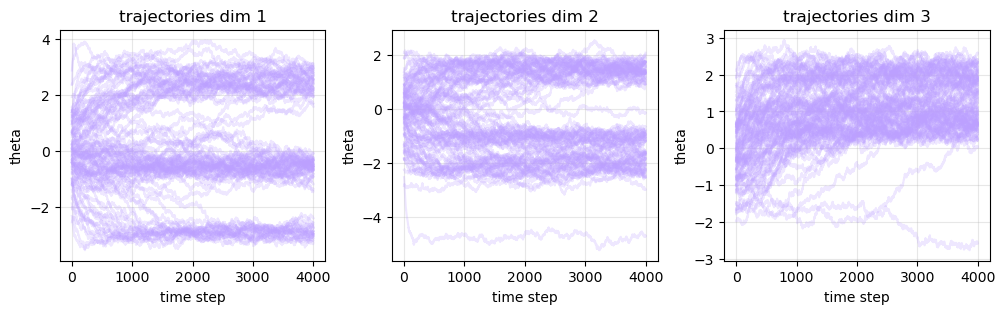

In [31]:
def kde_1d(samples, grid, bw=0.35):
    samples = samples.reshape(-1, 1)
    grid = grid.reshape(1, -1)
    u = (grid - samples) / bw
    kern = np.exp(-0.5 * u ** 2) / (np.sqrt(2.0 * np.pi) * bw)
    return np.mean(kern, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), gridspec_kw={"wspace": 0.25})
steps = np.arange(traj.shape[0]) if store_trajectory else None

for dim, ax in enumerate(axes):
    if store_trajectory:
        for j in range(traj.shape[1]):
            ax.plot(steps, traj[:, j, dim], color="#bca0ff", alpha=0.25)
    ax.set(title=f"trajectories dim {dim + 1}", xlabel="time step", ylabel="theta")
    ax.grid(alpha=0.3)

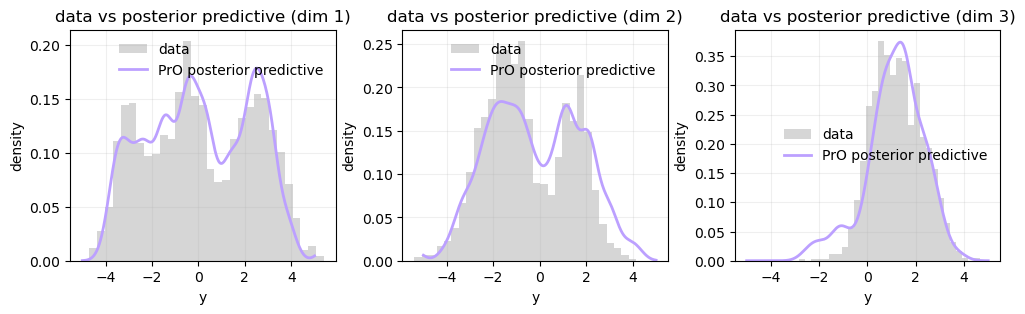

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), gridspec_kw={"wspace": 0.25})
grid = np.linspace(-5, 5, 400)
for dim, ax in enumerate(axes):
    ax.hist(y[:, dim], bins=30, density=True, alpha=0.4, color="0.6", label="data")
    ax.plot(grid, kde_1d(y_rep[:, dim], grid), color="#bca0ff", lw=2, label="PrO posterior predictive")
    ax.set(title=f"data vs posterior predictive (dim {dim + 1})", xlabel="y", ylabel="density")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)

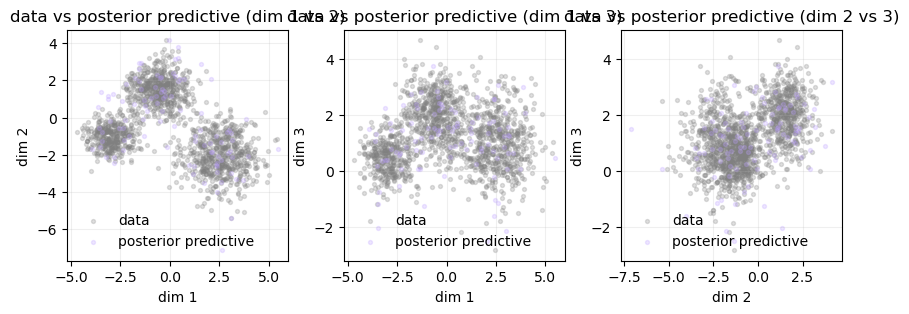

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), gridspec_kw={"wspace": 0.25})
pairs = [(0, 1), (0, 2), (1, 2)]
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(y[:, i], y[:, j], s=8, alpha=0.25, color="0.5", label="data")
    ax.scatter(y_rep[:, i], y_rep[:, j], s=8, alpha=0.25, color="#bca0ff", label="posterior predictive")
    ax.set(title=f"data vs posterior predictive (dim {i + 1} vs {j + 1})", xlabel=f"dim {i + 1}", ylabel=f"dim {j + 1}")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)

## Posterior predictive fit

We generate many replicated datasets by resampling particles and observation noise,
then compare simple summaries to the observed data:
- PPC mean: distribution of per-replicate means vs the observed mean.
- PPC std: distribution of per-replicate stds vs the observed std.
If the data line falls in the bulk of the histogram, the fit is good;
if it sits in the tails, the predictive is miscalibrated.

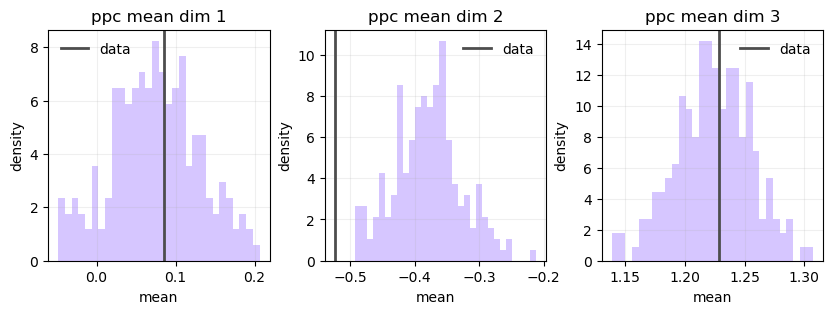

In [34]:
rng_ppc_stats = np.random.default_rng(2025)
n_ppc_rep = 200
ppc_idx = rng_ppc_stats.integers(0, final_particles.shape[0], size=(n_ppc_rep, n))
ppc_means = final_particles[ppc_idx]
y_ppc = rng_ppc_stats.normal(loc=ppc_means, scale=sigma, size=ppc_means.shape)
ppc_mean = np.mean(y_ppc, axis=1)
ppc_std = np.std(y_ppc, axis=1)
obs_mean = np.mean(y, axis=0)
obs_std = np.std(y, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(10, 3), gridspec_kw={"wspace": 0.25})
for dim, ax in enumerate(axes):
    ax.hist(ppc_mean[:, dim], bins=30, density=True, color="#bca0ff", alpha=0.6)
    ax.axvline(obs_mean[dim], color="0.3", lw=2, label="data")
    ax.set(title=f"ppc mean dim {dim + 1}", xlabel="mean", ylabel="density")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)

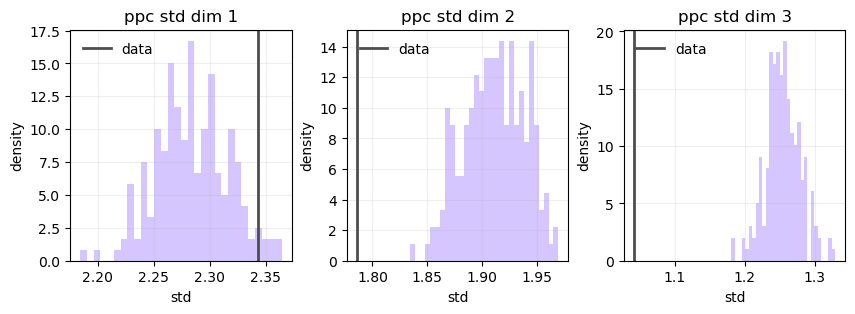

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), gridspec_kw={"wspace": 0.25})
for dim, ax in enumerate(axes):
    ax.hist(ppc_std[:, dim], bins=30, density=True, color="#bca0ff", alpha=0.6)
    ax.axvline(obs_std[dim], color="0.3", lw=2, label="data")
    ax.set(title=f"ppc std dim {dim + 1}", xlabel="std", ylabel="density")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)

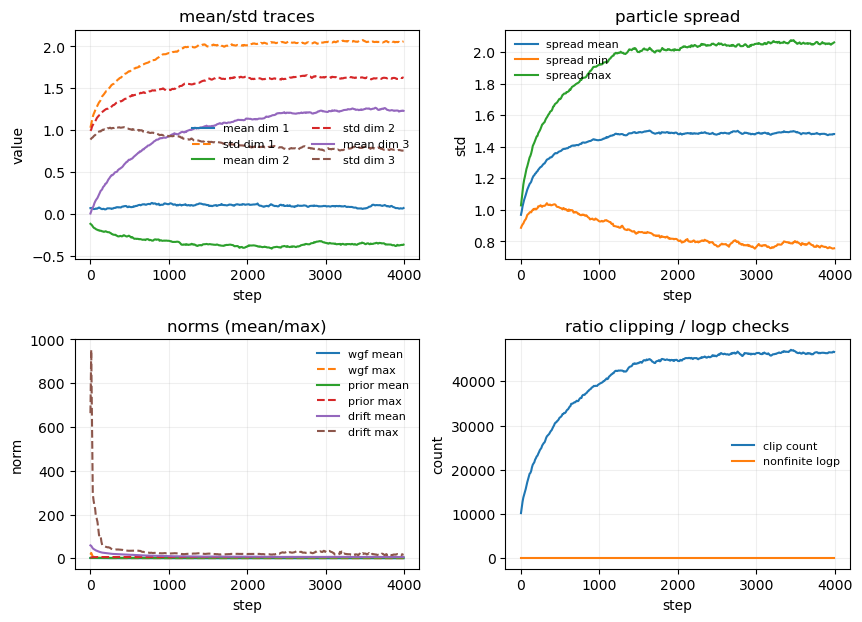

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), gridspec_kw={"hspace": 0.35, "wspace": 0.25})
axes = axes.ravel()

for dim in range(d):
    axes[0].plot(diag_steps, mean_trace[:, dim], label=f"mean dim {dim + 1}")
    axes[0].plot(diag_steps, std_trace[:, dim], ls="--", label=f"std dim {dim + 1}")
axes[0].set(title="mean/std traces", xlabel="step", ylabel="value")
axes[0].legend(frameon=False, ncol=2, fontsize=8)
axes[0].grid(alpha=0.2)

axes[1].plot(diag_steps, spread_mean, label="spread mean")
axes[1].plot(diag_steps, spread_min, label="spread min")
axes[1].plot(diag_steps, spread_max, label="spread max")
axes[1].set(title="particle spread", xlabel="step", ylabel="std")
axes[1].legend(frameon=False, fontsize=8)
axes[1].grid(alpha=0.2)

axes[2].plot(diag_steps, wgf_norm_mean, label="wgf mean")
axes[2].plot(diag_steps, wgf_norm_max, ls="--", label="wgf max")
axes[2].plot(diag_steps, prior_norm_mean, label="prior mean")
axes[2].plot(diag_steps, prior_norm_max, ls="--", label="prior max")
axes[2].plot(diag_steps, drift_norm_mean, label="drift mean")
axes[2].plot(diag_steps, drift_norm_max, ls="--", label="drift max")
axes[2].set(title="norms (mean/max)", xlabel="step", ylabel="norm")
axes[2].legend(frameon=False, fontsize=8)
axes[2].grid(alpha=0.2)

axes[3].plot(diag_steps, clip_counts, label="clip count")
axes[3].plot(diag_steps, nonfinite_logp, label="nonfinite logp")
axes[3].set(title="ratio clipping / logp checks", xlabel="step", ylabel="count")
axes[3].legend(frameon=False, fontsize=8)
axes[3].grid(alpha=0.2)